# Running an aquaplanet test case

First we set up the mpi environment:

In [1]:
from pyrte_rrtmgp.rrtmgp_data_files import download_rrtmgp_data

download_rrtmgp_data()

'/root/.cache/pyrte_rrtmgp/rrtmgp-data-1.9'

In [2]:
import ipyparallel as ipp
ntiles = 6
layout = (1, 1)

num_ranks = ntiles * layout[0] * layout[1]
cluster = ipp.Cluster(engines="mpi", n=num_ranks).start_and_connect_sync()

# start executing cells on the workers in parallel from here on
%autopx

Starting 6 engines with <class 'ipyparallel.cluster.launcher.MPIEngineSetLauncher'>
100%|███████████████████████████████████████████████████████████████████████| 6/6 [00:05<00:00,  1.09engine/s]
%autopx enabled


[1:execute]
---------------------------------------------------------------------------
ContainsArrayError                        Traceback (most recent call last)
Cell In[7], line 1
----> 1 get_ipython().run_cell_magic('time', '', 'try:\n    driver.step_all()\nfinally:\n    driver.cleanup()\n')

File /usr/local/lib/python3.12/site-packages/IPython/core/interactiveshell.py:2593, in InteractiveShell.run_cell_magic(self, magic_name, line, cell)
   2591 with self.builtin_trap:
   2592     args = (magic_arg_s, cell)
-> 2593     result = fn(*args, **kwargs)
   2595 # The code below prevents the output from being displayed
   2596 # when using magics with decorator @output_can_be_silenced
   2597 # when the last Python token in the expression is a ';'.
   2598 if getattr(fn, magic.MAGIC_OUTPUT_CAN_BE_SILENCED, False):

File /usr/local/lib/python3.12/site-packages/IPython/core/magics/execution.py:1448, in ExecutionMagics.time(self, line, cell, local_ns)
   1446 if interrupt_occured:
   1447  

In [3]:
from mpi4py import MPI

mpi_comm = MPI.COMM_WORLD
mpi_size = mpi_comm.Get_size()
mpi_rank = mpi_comm.Get_rank()

print(f"I am MPI-rank {mpi_rank} of a total of {mpi_size}")

[stdout:0] I am MPI-rank 0 of a total of 6


[stdout:2] I am MPI-rank 2 of a total of 6


[stdout:1] I am MPI-rank 1 of a total of 6


[stdout:3] I am MPI-rank 3 of a total of 6


[stdout:4] I am MPI-rank 4 of a total of 6


[stdout:5] I am MPI-rank 5 of a total of 6


In [4]:
%%time

from pace import Driver, DriverConfig
import yaml
import os

os.environ['HDF5_USE_FILE_LOCKING'] = 'FALSE'

config_file = "aquaplanet_c16.yaml"

with open(config_file, "r") as f:
    driver_config = DriverConfig.from_dict(yaml.safe_load(f))
driver = Driver(config=driver_config)

[output:3]

[output:1]

[output:0]

[output:5]

[output:2]

...

[stderr:4] /usr/local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/usr/local/lib/python3.12/site-packages/ndsl/grid/generation.py:1550: RuntimeWarning: divide by zero encountered in divide
  data=1.0 / self.area.data,
/usr/local/lib/python3.12/site-packages/ndsl/grid/gnomonic.py:681: RuntimeWarning: invalid value encountered in divide
  np.sum(p * q, axis=-1) / np.sqrt(np.sum(p**2, axis=-1) * np.sum(q**2, axis=-1))
/usr/local/lib/python3.12/site-packages/ndsl/grid/gnomonic.py:681: RuntimeWarning: invalid value encountered in scalar divide
  np.sum(p * q, axis=-1) / np.sqrt(np.sum(p**2, axis=-1) * np.sum(q**2, axis=-1))
/usr/local/lib/python3.12/site-packages/ndsl/grid/generation.py:1565: RuntimeWarning: divide by zero encountered in divide
  data=1.0 / self.area_c.data,
/usr/local/lib/python3.12/sit

[stderr:0] /usr/local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/usr/local/lib/python3.12/site-packages/ndsl/grid/generation.py:1550: RuntimeWarning: divide by zero encountered in divide
  data=1.0 / self.area.data,
/usr/local/lib/python3.12/site-packages/ndsl/grid/gnomonic.py:681: RuntimeWarning: invalid value encountered in divide
  np.sum(p * q, axis=-1) / np.sqrt(np.sum(p**2, axis=-1) * np.sum(q**2, axis=-1))
/usr/local/lib/python3.12/site-packages/ndsl/grid/gnomonic.py:681: RuntimeWarning: invalid value encountered in scalar divide
  np.sum(p * q, axis=-1) / np.sqrt(np.sum(p**2, axis=-1) * np.sum(q**2, axis=-1))
/usr/local/lib/python3.12/site-packages/ndsl/grid/generation.py:1565: RuntimeWarning: divide by zero encountered in divide
  data=1.0 / self.area_c.data,
/usr/local/lib/python3.12/sit

%px:   0%|                                                                           | 0/6 [00:01<?, ?tasks/s]

[stderr:2] /usr/local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/usr/local/lib/python3.12/site-packages/ndsl/grid/generation.py:1550: RuntimeWarning: divide by zero encountered in divide
  data=1.0 / self.area.data,
/usr/local/lib/python3.12/site-packages/ndsl/grid/gnomonic.py:681: RuntimeWarning: invalid value encountered in divide
  np.sum(p * q, axis=-1) / np.sqrt(np.sum(p**2, axis=-1) * np.sum(q**2, axis=-1))
/usr/local/lib/python3.12/site-packages/ndsl/grid/gnomonic.py:681: RuntimeWarning: invalid value encountered in scalar divide
  np.sum(p * q, axis=-1) / np.sqrt(np.sum(p**2, axis=-1) * np.sum(q**2, axis=-1))
/usr/local/lib/python3.12/site-packages/ndsl/grid/generation.py:1565: RuntimeWarning: divide by zero encountered in divide
  data=1.0 / self.area_c.data,
/usr/local/lib/python3.12/sit

%px: 100%|███████████████████████████████████████████████████████████████████| 6/6 [01:41<00:00, 16.98s/tasks]


In [5]:
if mpi_rank == 0:
    print(driver.state.grid_data.lon_agrid.shape)
    print(driver_config.physics_config.nsswr)
    print(driver_config.physics_config.dt_atmos)

[stdout:0] (31, 31)
1
900


We can inspect the initial model state:

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from cartopy import crs as ccrs
from fv3viz import pcolormesh_cube
from ndsl import CubedSphereCommunicator

communicator = CubedSphereCommunicator.from_layout(
    comm=driver.comm,
    layout=driver.config.layout,
)
u_wind = communicator.gather(driver.state.dycore_state.u)
temperature = communicator.gather(driver.state.dycore_state.pt)
surface_pressure = communicator.gather(driver.state.dycore_state.ps)
edge_pressure = communicator.gather(driver.state.dycore_state.pe)
grid_lon = communicator.gather(driver.state.grid_data.lon)
grid_lat = communicator.gather(driver.state.grid_data.lat)
a_lon = communicator.gather(driver.state.grid_data.lon_agrid)
a_lat = communicator.gather(driver.state.grid_data.lat_agrid)

[stdout:0] (6, 24, 24, 79)
(6, 25, 25)
(6, 25, 25)
(31, 31, 80)
0.0 0.0
0.0 0.0
0.0 0.0
0.0 0.0
0.0 0.0
0.0 0.0
0.0 0.0
0.0 0.0
0.0 0.0
0.0 0.0
0.0 0.0
0.0 0.0


[output:0]

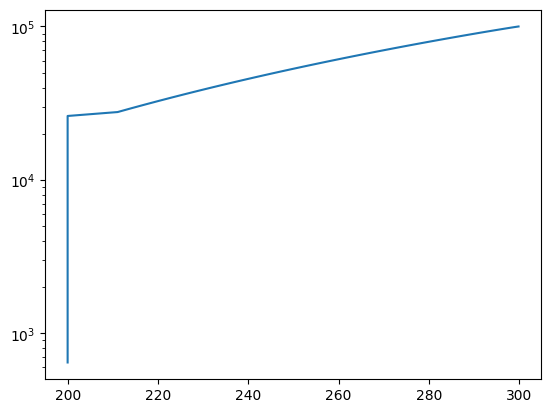

In [7]:
if mpi_rank == 0:
    print(temperature.shape)
    print(grid_lon.data.shape)
    print(grid_lat.shape)
    print(driver.state.dycore_state.pt.shape)
#     print(driver.state.dycore_state.pt.field[:,:,-2])
    for r in range(6):
        print(temperature.field[r, :, :, -2].min(), temperature.field[r, :, :, -2].max())
        print(surface_pressure.field[r, :, :].min(), surface_pressure.field[r, :, :].max())
    plt.semilogy(driver.state.dycore_state.pt.field[6, 6, :], driver.state.dycore_state.pe.field[6, 6, 1:])

[stdout:0] 0.0


[output:0]

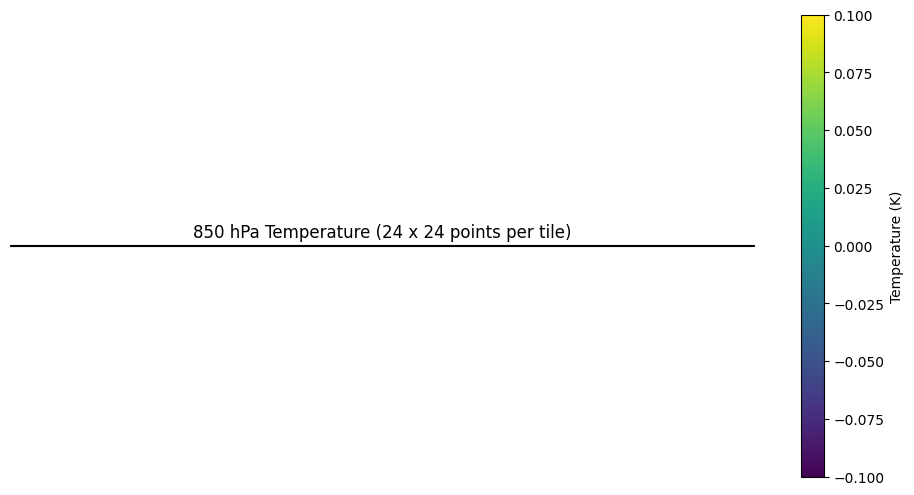

[output:0]

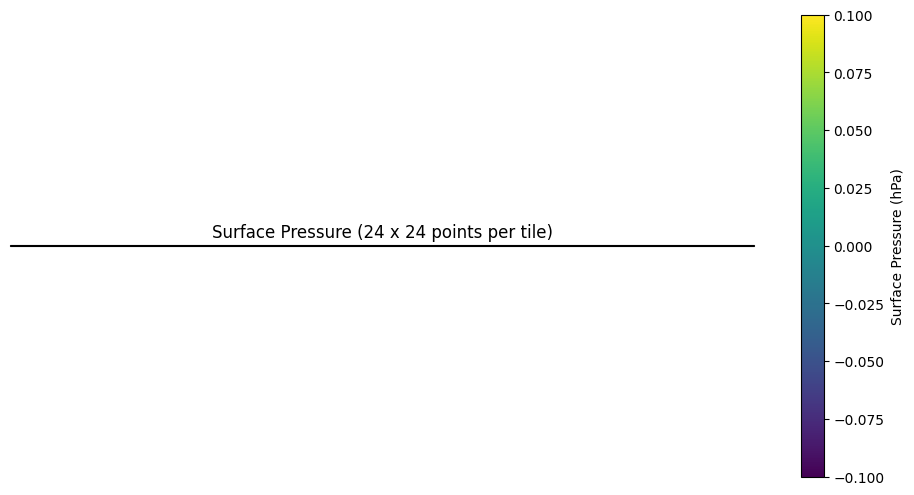

In [8]:
if mpi_rank == 0:
    nx=12
    u_mean = 0.5 * (u_wind.field[:,:,:-1, :] + u_wind.field[:,:, 1:, :])
    print(temperature.field[:, :, :, -2].min())
    
    nx = temperature.shape[1]
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f1 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi,
        temperature.field[:, :, :, -2],
        cmap="viridis",
    )
    plt.colorbar(f1, label="Temperature (K)")
    ax.set_title(f"850 hPa Temperature ({nx} x {nx} points per tile)")
    
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f1 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi,
        edge_pressure.data[:, :, :, 0]/100.,
        cmap="viridis",
    )
    plt.colorbar(f1, label="Surface Pressure (hPa)")
    ax.set_title(f"Surface Pressure ({nx} x {nx} points per tile)")
    
    
#     fig = plt.figure(figsize=(12, 6))
#     ax = fig.add_subplot(111, projection=ccrs.Robinson())
#     f1 = pcolormesh_cube(
#         grid_lat.data * 180./np.pi,
#         grid_lon.data * 180./np.pi,
#         u_mean[:,:,:,65],
#         cmap="bwr",
#     )
#     plt.colorbar(f1, label="U wind (m/s)")
#     ax.set_title(f"U Wind ({nx} x {nx} points per tile)")

And then we can run the model:

In [ ]:
%%time
try:
    driver.step_all()
finally:
    driver.cleanup()

[stdout:1] 2026-03-11 20:25:22|INFO|rank 1|ndsl.logging:integrating driver forward in time
2026-03-11 20:25:22|WARNING|rank 1|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis i: 24 < 30.
2026-03-11 20:25:22|WARNING|rank 1|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis j: 24 < 30.
2026-03-11 20:25:22|WARNING|rank 1|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis i_interface: 25 < 30.
2026-03-11 20:25:22|WARNING|rank 1|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis j: 24 < 30.
2026-03-11 20:25:22|WARNING|rank 1|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis i: 24 < 30.
2026-03-11 20:25:22|WARNING|rank 1|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis j_interface: 25 < 30.
2026-03-11 20:25:22|WARNING|rank 1|ndsl.logging:Quantity `cxd` is too small for the targeted domain in axis i_interface: 25 < 30.
2026-03-11 20:25:22|WARNING|rank 

[stdout:4] 2026-03-11 20:25:22|INFO|rank 4|ndsl.logging:integrating driver forward in time
2026-03-11 20:25:22|WARNING|rank 4|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis i: 24 < 30.
2026-03-11 20:25:22|WARNING|rank 4|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis j: 24 < 30.
2026-03-11 20:25:22|WARNING|rank 4|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis i_interface: 25 < 30.
2026-03-11 20:25:22|WARNING|rank 4|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis j: 24 < 30.
2026-03-11 20:25:22|WARNING|rank 4|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis i: 24 < 30.
2026-03-11 20:25:22|WARNING|rank 4|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis j_interface: 25 < 30.
2026-03-11 20:25:22|WARNING|rank 4|ndsl.logging:Quantity `cxd` is too small for the targeted domain in axis i_interface: 25 < 30.
2026-03-11 20:25:22|WARNING|rank 

[stdout:0] 2026-03-11 20:25:22|INFO|rank 0|ndsl.logging:integrating driver forward in time
2026-03-11 20:25:22|INFO|rank 0|ndsl.logging:FV Setup
2026-03-11 20:25:22|INFO|rank 0|ndsl.logging:Adjust pt
2026-03-11 20:25:22|WARNING|rank 0|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis i: 24 < 30.
2026-03-11 20:25:22|WARNING|rank 0|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis j: 24 < 30.
2026-03-11 20:25:22|INFO|rank 0|ndsl.logging:DynCore
2026-03-11 20:25:22|WARNING|rank 0|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis i_interface: 25 < 30.
2026-03-11 20:25:22|WARNING|rank 0|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis j: 24 < 30.
2026-03-11 20:25:22|WARNING|rank 0|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis i: 24 < 30.
2026-03-11 20:25:22|WARNING|rank 0|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis j_interface: 25 < 30.
2

[stdout:5] 2026-03-11 20:25:22|INFO|rank 5|ndsl.logging:integrating driver forward in time
2026-03-11 20:25:22|WARNING|rank 5|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis i: 24 < 30.
2026-03-11 20:25:22|WARNING|rank 5|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis j: 24 < 30.
2026-03-11 20:25:22|WARNING|rank 5|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis i_interface: 25 < 30.
2026-03-11 20:25:22|WARNING|rank 5|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis j: 24 < 30.
2026-03-11 20:25:22|WARNING|rank 5|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis i: 24 < 30.
2026-03-11 20:25:22|WARNING|rank 5|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis j_interface: 25 < 30.
2026-03-11 20:25:22|WARNING|rank 5|ndsl.logging:Quantity `cxd` is too small for the targeted domain in axis i_interface: 25 < 30.
2026-03-11 20:25:22|WARNING|rank 

[stdout:3] 2026-03-11 20:25:22|INFO|rank 3|ndsl.logging:integrating driver forward in time
2026-03-11 20:25:22|WARNING|rank 3|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis i: 24 < 30.
2026-03-11 20:25:22|WARNING|rank 3|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis j: 24 < 30.
2026-03-11 20:25:22|WARNING|rank 3|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis i_interface: 25 < 30.
2026-03-11 20:25:22|WARNING|rank 3|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis j: 24 < 30.
2026-03-11 20:25:22|WARNING|rank 3|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis i: 24 < 30.
2026-03-11 20:25:22|WARNING|rank 3|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis j_interface: 25 < 30.
2026-03-11 20:25:22|WARNING|rank 3|ndsl.logging:Quantity `cxd` is too small for the targeted domain in axis i_interface: 25 < 30.
2026-03-11 20:25:22|WARNING|rank 

[stdout:2] 2026-03-11 20:25:22|INFO|rank 2|ndsl.logging:integrating driver forward in time
2026-03-11 20:25:22|WARNING|rank 2|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis i: 24 < 30.
2026-03-11 20:25:22|WARNING|rank 2|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis j: 24 < 30.
2026-03-11 20:25:22|WARNING|rank 2|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis i_interface: 25 < 30.
2026-03-11 20:25:22|WARNING|rank 2|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis j: 24 < 30.
2026-03-11 20:25:22|WARNING|rank 2|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis i: 24 < 30.
2026-03-11 20:25:22|WARNING|rank 2|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis j_interface: 25 < 30.
2026-03-11 20:25:22|WARNING|rank 2|ndsl.logging:Quantity `cxd` is too small for the targeted domain in axis i_interface: 25 < 30.
2026-03-11 20:25:22|WARNING|rank 

%px:   0%|                                                                           | 0/6 [00:00<?, ?tasks/s]

IOPub message rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_msg_rate_limit`.

Current values:
NotebookApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
NotebookApp.rate_limit_window=3.0 (secs)



%px:  83%|███████████████████████████████████████████████████████▊           | 5/6 [00:23<00:00, 17.14tasks/s]

Now let's investigate the model state

In [14]:
u_wind = communicator.gather(driver.state.dycore_state.u)
temperature = communicator.gather(driver.state.dycore_state.pt)
surface_pressure = communicator.gather(driver.state.dycore_state.ps)
grid_lon = communicator.gather(driver.state.grid_data.lon)
grid_lat = communicator.gather(driver.state.grid_data.lat)
a_lon = communicator.gather(driver.state.grid_data.lon_agrid)
a_lat = communicator.gather(driver.state.grid_data.lat_agrid)
qvap = communicator.gather(driver.state.dycore_state.qvapor)
qcld = communicator.gather(driver.state.dycore_state.qcld)
qrain = communicator.gather(driver.state.dycore_state.qrain)

In [15]:
if mpi_rank == 0:
    print(temperature.data[:,:,:,-2].shape)
    print(grid_lat.data.shape)
    print(grid_lon.data.shape)
    print(np.all(np.isnan(u_wind.data)))

[stdout:0] (6, 24, 24)
(6, 25, 25)
(6, 25, 25)
False


[output:0]

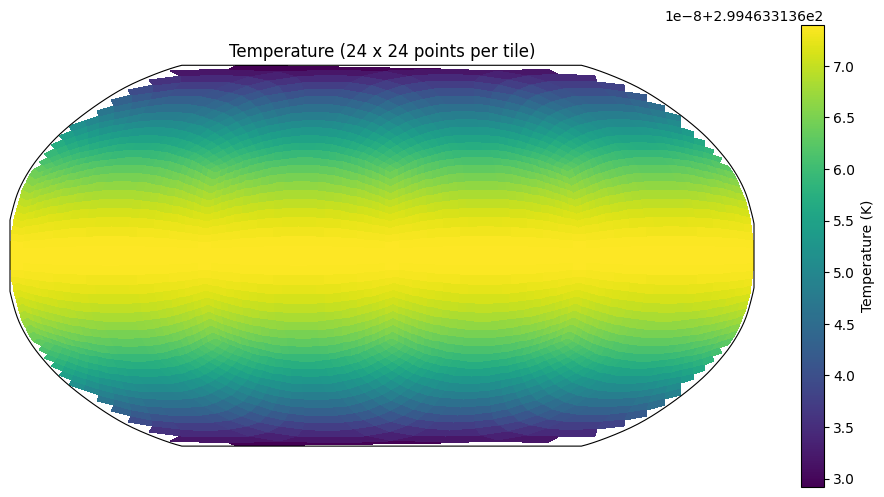

[output:0]

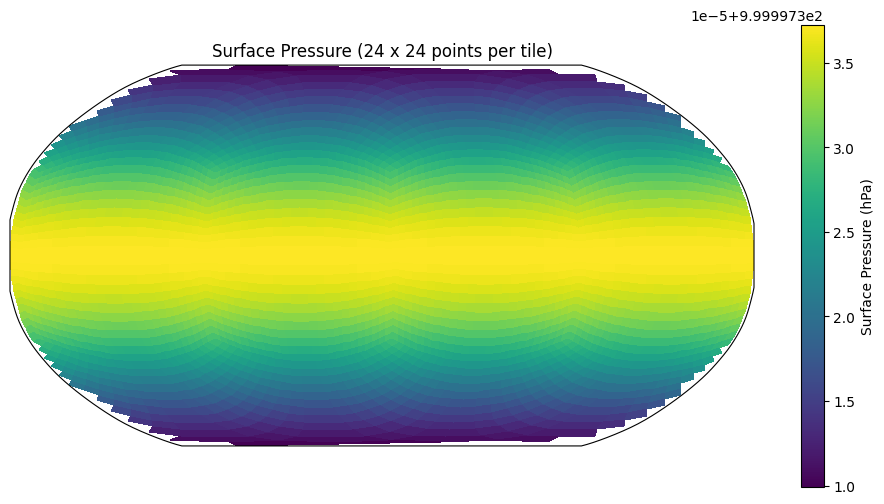

[output:0]

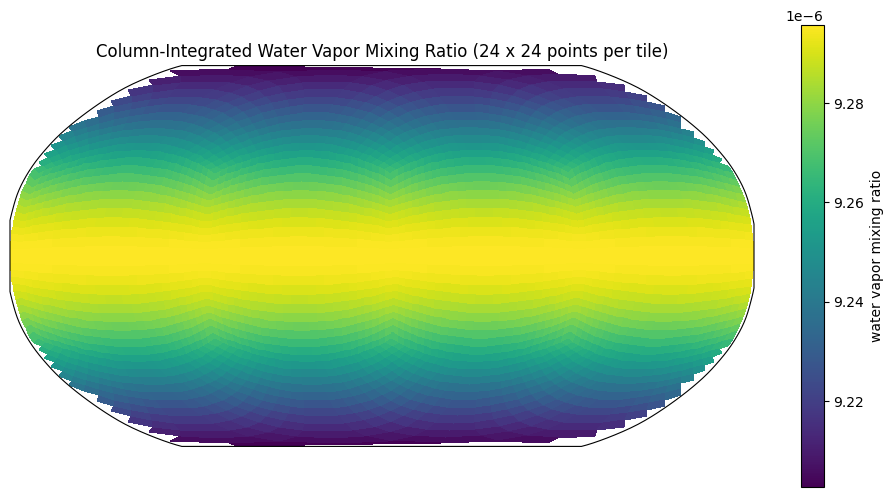

[output:0]

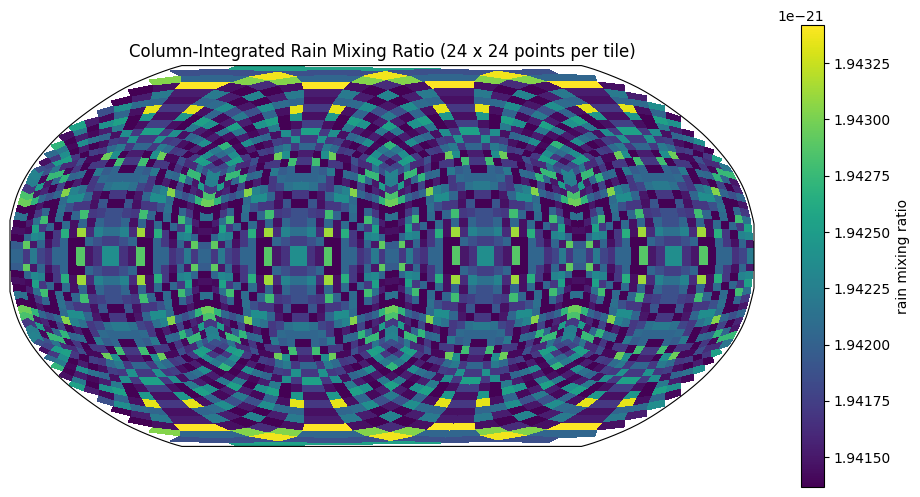

[output:0]

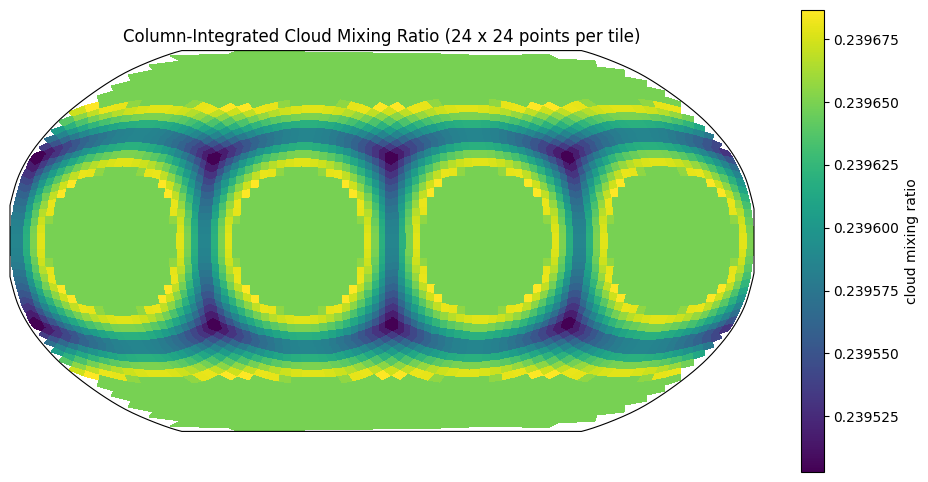

In [16]:
if mpi_rank == 0:
    rotation = -120.
    nx = temperature.shape[1]
    nz = temperature.shape[3]
    
    u_mean = 0.5 * (u_wind.data[:,:,:-1, :] + u_wind.data[:,:, 1:, :])
    column_qvap = np.sum(qvap, axis=3)/nz
    column_qcld = np.sum(qcld, axis=3)/nz
    column_qrain = np.sum(qrain, axis=3)/nz
    
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f1 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi + rotation,
        temperature.data[:, :, :, -2],
        cmap="viridis",
    )
    plt.colorbar(f1, label="Temperature (K)")
    ax.set_title(f"Temperature ({nx} x {nx} points per tile)")
    
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f1 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi + rotation,
        surface_pressure.data[:, :, :]/100.,
        cmap="viridis",
    )
    plt.colorbar(f1, label="Surface Pressure (hPa)")
    ax.set_title(f"Surface Pressure ({nx} x {nx} points per tile)")
    
    
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f1 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi + rotation,
        column_qvap,
        cmap="viridis",
    )
    plt.colorbar(f1, label="water vapor mixing ratio")
    ax.set_title(f"Column-Integrated Water Vapor Mixing Ratio ({nx} x {nx} points per tile)")
    

    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f1 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi + rotation,
        column_qrain,
        cmap="viridis",
    )
    plt.colorbar(f1, label="rain mixing ratio")
    ax.set_title(f"Column-Integrated Rain Mixing Ratio ({nx} x {nx} points per tile)")
    
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f1 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi + rotation,
        column_qcld,
        cmap="viridis",
    )
    plt.colorbar(f1, label="cloud mixing ratio")
    ax.set_title(f"Column-Integrated Cloud Mixing Ratio ({nx} x {nx} points per tile)")

Now let's step through

In [18]:
# for n in range(59):
#     driver.step_one(n+1)

[stdout:0] 2026-03-06 20:36:44|INFO|rank 0|ndsl.logging:integrating driver forward in time
2026-03-06 20:36:44|INFO|rank 0|ndsl.logging:FV Setup
2026-03-06 20:36:44|INFO|rank 0|ndsl.logging:Adjust pt
2026-03-06 20:36:44|INFO|rank 0|ndsl.logging:DynCore
2026-03-06 20:36:44|INFO|rank 0|ndsl.logging:TracerAdvection
2026-03-06 20:36:45|INFO|rank 0|ndsl.logging:Remapping
2026-03-06 20:36:47|INFO|rank 0|ndsl.logging:Omega
2026-03-06 20:36:47|INFO|rank 0|ndsl.logging:Del2Cubed
2026-03-06 20:36:47|INFO|rank 0|ndsl.logging:Neg Adj 3
2026-03-06 20:36:47|INFO|rank 0|ndsl.logging:CubedToLatLon
2026-03-06 20:36:47|INFO|rank 0|ndsl.logging:Entering radiation
2026-03-06 20:36:47|INFO|rank 0|ndsl.logging:writing radiation state to xarray
2026-03-06 20:36:53|INFO|rank 0|ndsl.logging:Exiting radiation
2026-03-06 20:37:04|INFO|rank 0|ndsl.logging:Finished stepping 0
2026-03-06 20:37:04|INFO|rank 0|ndsl.logging:diagnostics for step 2000-01-01 00:15:00 started
2026-03-06 20:37:04|INFO|rank 0|ndsl.logging:d

[stdout:2] 2026-03-06 20:36:44|INFO|rank 2|ndsl.logging:integrating driver forward in time
2026-03-06 20:36:47|INFO|rank 2|ndsl.logging:Entering radiation
2026-03-06 20:36:47|INFO|rank 2|ndsl.logging:writing radiation state to xarray
2026-03-06 20:36:52|INFO|rank 2|ndsl.logging:Exiting radiation
2026-03-06 20:37:04|INFO|rank 2|ndsl.logging:Finished stepping 0
2026-03-06 20:37:04|INFO|rank 2|ndsl.logging:diagnostics for step 2000-01-01 00:15:00 started
2026-03-06 20:37:04|INFO|rank 2|ndsl.logging:diagnostics for step 2000-01-01 00:15:00 finished
2026-03-06 20:37:04|INFO|rank 2|ndsl.logging:integrating driver forward in time
2026-03-06 20:37:07|INFO|rank 2|ndsl.logging:Entering radiation
2026-03-06 20:37:07|INFO|rank 2|ndsl.logging:writing radiation state to xarray
2026-03-06 20:37:12|INFO|rank 2|ndsl.logging:Exiting radiation
2026-03-06 20:37:22|INFO|rank 2|ndsl.logging:Finished stepping 0
2026-03-06 20:37:22|INFO|rank 2|ndsl.logging:diagnostics for step 2000-01-01 00:22:30 started
2026

[stdout:1] 2026-03-06 20:36:44|INFO|rank 1|ndsl.logging:integrating driver forward in time
2026-03-06 20:36:47|INFO|rank 1|ndsl.logging:Entering radiation
2026-03-06 20:36:47|INFO|rank 1|ndsl.logging:writing radiation state to xarray
2026-03-06 20:36:53|INFO|rank 1|ndsl.logging:Exiting radiation
2026-03-06 20:37:04|INFO|rank 1|ndsl.logging:Finished stepping 0
2026-03-06 20:37:04|INFO|rank 1|ndsl.logging:diagnostics for step 2000-01-01 00:15:00 started
2026-03-06 20:37:04|INFO|rank 1|ndsl.logging:diagnostics for step 2000-01-01 00:15:00 finished
2026-03-06 20:37:04|INFO|rank 1|ndsl.logging:integrating driver forward in time
2026-03-06 20:37:07|INFO|rank 1|ndsl.logging:Entering radiation
2026-03-06 20:37:07|INFO|rank 1|ndsl.logging:writing radiation state to xarray
2026-03-06 20:37:12|INFO|rank 1|ndsl.logging:Exiting radiation
2026-03-06 20:37:22|INFO|rank 1|ndsl.logging:Finished stepping 0
2026-03-06 20:37:22|INFO|rank 1|ndsl.logging:diagnostics for step 2000-01-01 00:22:30 started
2026

[stdout:3] 2026-03-06 20:36:44|INFO|rank 3|ndsl.logging:integrating driver forward in time
2026-03-06 20:36:47|INFO|rank 3|ndsl.logging:Entering radiation
2026-03-06 20:36:47|INFO|rank 3|ndsl.logging:writing radiation state to xarray
2026-03-06 20:36:53|INFO|rank 3|ndsl.logging:Exiting radiation
2026-03-06 20:37:04|INFO|rank 3|ndsl.logging:Finished stepping 0
2026-03-06 20:37:04|INFO|rank 3|ndsl.logging:diagnostics for step 2000-01-01 00:15:00 started
2026-03-06 20:37:04|INFO|rank 3|ndsl.logging:diagnostics for step 2000-01-01 00:15:00 finished
2026-03-06 20:37:04|INFO|rank 3|ndsl.logging:integrating driver forward in time
2026-03-06 20:37:07|INFO|rank 3|ndsl.logging:Entering radiation
2026-03-06 20:37:07|INFO|rank 3|ndsl.logging:writing radiation state to xarray
2026-03-06 20:37:12|INFO|rank 3|ndsl.logging:Exiting radiation
2026-03-06 20:37:22|INFO|rank 3|ndsl.logging:Finished stepping 0
2026-03-06 20:37:22|INFO|rank 3|ndsl.logging:diagnostics for step 2000-01-01 00:22:30 started
2026

[stdout:4] 2026-03-06 20:36:44|INFO|rank 4|ndsl.logging:integrating driver forward in time
2026-03-06 20:36:47|INFO|rank 4|ndsl.logging:Entering radiation
2026-03-06 20:36:47|INFO|rank 4|ndsl.logging:writing radiation state to xarray
2026-03-06 20:36:53|INFO|rank 4|ndsl.logging:Exiting radiation
2026-03-06 20:37:04|INFO|rank 4|ndsl.logging:Finished stepping 0
2026-03-06 20:37:04|INFO|rank 4|ndsl.logging:diagnostics for step 2000-01-01 00:15:00 started
2026-03-06 20:37:04|INFO|rank 4|ndsl.logging:diagnostics for step 2000-01-01 00:15:00 finished
2026-03-06 20:37:04|INFO|rank 4|ndsl.logging:integrating driver forward in time
2026-03-06 20:37:07|INFO|rank 4|ndsl.logging:Entering radiation
2026-03-06 20:37:07|INFO|rank 4|ndsl.logging:writing radiation state to xarray
2026-03-06 20:37:12|INFO|rank 4|ndsl.logging:Exiting radiation
2026-03-06 20:37:22|INFO|rank 4|ndsl.logging:Finished stepping 0
2026-03-06 20:37:22|INFO|rank 4|ndsl.logging:diagnostics for step 2000-01-01 00:22:30 started
2026

[stdout:5] 2026-03-06 20:36:44|INFO|rank 5|ndsl.logging:integrating driver forward in time
2026-03-06 20:36:47|INFO|rank 5|ndsl.logging:Entering radiation
2026-03-06 20:36:47|INFO|rank 5|ndsl.logging:writing radiation state to xarray
2026-03-06 20:36:53|INFO|rank 5|ndsl.logging:Exiting radiation
2026-03-06 20:37:04|INFO|rank 5|ndsl.logging:Finished stepping 0
2026-03-06 20:37:04|INFO|rank 5|ndsl.logging:diagnostics for step 2000-01-01 00:15:00 started
2026-03-06 20:37:04|INFO|rank 5|ndsl.logging:diagnostics for step 2000-01-01 00:15:00 finished
2026-03-06 20:37:04|INFO|rank 5|ndsl.logging:integrating driver forward in time
2026-03-06 20:37:07|INFO|rank 5|ndsl.logging:Entering radiation
2026-03-06 20:37:07|INFO|rank 5|ndsl.logging:writing radiation state to xarray
2026-03-06 20:37:12|INFO|rank 5|ndsl.logging:Exiting radiation
2026-03-06 20:37:22|INFO|rank 5|ndsl.logging:Finished stepping 0
2026-03-06 20:37:22|INFO|rank 5|ndsl.logging:diagnostics for step 2000-01-01 00:22:30 started
2026

%px: 100%|██████████████████████████████████████████████████████████████████| 6/6 [13:04<00:00, 130.70s/tasks]


AlreadyDisplayedError: 6 errors

In [19]:
temperature = communicator.gather(driver.state.dycore_state.pt)
surface_pressure = communicator.gather(driver.state.dycore_state.ps)
edge_pressure = communicator.gather(driver.state.dycore_state.pe)
u_wind = communicator.gather(driver.state.dycore_state.u)
v_wind = communicator.gather(driver.state.dycore_state.v)

NoEnginesRegistered: This operation requires engines. Try client.wait_for_engines(n) to wait for engines to register.